In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.metrics import (
    mean_absolute_error
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [2]:
df_raw = pd.read_csv("sleep_health_dataset.csv")
df_raw

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,44,Female,Nurse,25.9,USA,6.77,6.3,26.8,24.6,...,72,1,0,19.1,1.93,Spring,Weekend,89.4,Healthy,1
99996,99997,44,Female,Manager,30.2,India,4.90,4.1,21.6,22.3,...,80,1,0,18.6,1.44,Spring,Weekday,40.5,Mild,0
99997,99998,39,Male,Manager,29.2,Brazil,5.94,5.1,21.4,14.3,...,74,1,0,19.4,0.62,Spring,Weekday,64.8,Healthy,1
99998,99999,33,Female,Nurse,27.3,India,5.27,3.0,21.9,23.6,...,68,1,0,20.6,2.32,Winter,Weekend,40.8,Mild,0


<h1>Understanding the data

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [4]:
df_regression = df_raw[["age","gender","occupation","bmi","sleep_duration_hrs","rem_percentage","deep_sleep_percentage","sleep_latency_mins","wake_episodes_per_night","exercise_day","nap_duration_mins","stress_score","work_hours_that_day","chronotype","mental_health_condition","sleep_aid_used","shift_work","heart_rate_resting_bpm","caffeine_mg_before_bed","cognitive_performance_score"]].copy()

In [5]:
df_regression.head()

,age,gender,occupation,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,sleep_aid_used,shift_work,heart_rate_resting_bpm,caffeine_mg_before_bed,cognitive_performance_score
0,29,Female,Driver,25.7,6.19,22.5,19.3,16,3,0,0,4.4,10.7,Morning,Healthy,0,0,63,0,73.4
1,55,Female,Software Engineer,22.0,8.32,26.9,14.9,17,4,1,8,4.0,3.0,Neutral,Healthy,1,0,52,0,99.4
2,42,Male,Nurse,25.0,3.74,20.2,16.2,26,4,1,28,7.8,3.6,Neutral,Both,0,1,72,0,2.5
3,37,Female,Student,29.5,6.79,17.7,17.7,13,4,1,40,4.9,6.7,Morning,Healthy,0,0,71,0,67.8
4,23,Male,Lawyer,23.6,5.02,23.3,18.3,30,5,0,0,7.4,10.4,Neutral,Healthy,0,0,71,40,38.1


In [6]:
df_regression.describe()

,age,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,stress_score,work_hours_that_day,sleep_aid_used,shift_work,heart_rate_resting_bpm,caffeine_mg_before_bed,cognitive_performance_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,34.706870,26.289673,6.423986,20.243968,20.253375,19.836810,3.346610,0.450710,14.936840,5.733285,7.134059,0.561610,0.084420,66.57017,38.849500,59.227295
std,11.036373,4.479578,1.274627,3.411354,4.251096,7.584343,1.920877,0.497567,21.387567,1.619194,3.482878,0.496192,0.278018,7.22821,69.395818,22.249665
min,18.000000,16.000000,3.000000,10.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,45.00000,0.000000,0.000000
25%,26.000000,23.200000,5.530000,18.000000,17.400000,14.000000,2.000000,0.000000,0.000000,4.800000,4.700000,0.000000,0.000000,62.00000,0.000000,44.200000
50%,33.000000,26.300000,6.360000,20.300000,20.300000,19.000000,3.000000,0.000000,0.000000,5.800000,7.400000,1.000000,0.000000,67.00000,0.000000,60.400000
75%,42.000000,29.300000,7.270000,22.600000,23.200000,25.000000,5.000000,1.000000,30.000000,6.800000,9.700000,1.000000,0.000000,71.00000,80.000000,75.800000
max,69.000000,45.000000,10.500000,30.000000,30.000000,58.000000,8.000000,1.000000,116.000000,10.000000,18.000000,1.000000,1.000000,99.00000,400.000000,100.000000


In [7]:
df_regression[df_regression["work_hours_that_day"]== 18.0]

,age,gender,occupation,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,sleep_aid_used,shift_work,heart_rate_resting_bpm,caffeine_mg_before_bed,cognitive_performance_score
12137,37,Male,Lawyer,21.3,5.08,19.0,12.5,24,4,0,0,7.3,18.0,Morning,Healthy,1,0,75,80,33.0
20459,32,Female,Lawyer,36.6,5.95,24.5,20.0,20,8,1,22,5.9,18.0,Evening,Healthy,1,0,64,0,64.8
27578,34,Male,Doctor,23.0,6.10,18.0,17.6,22,5,0,0,7.8,18.0,Neutral,Healthy,0,0,60,100,49.2
82904,43,Female,Lawyer,28.1,5.49,24.4,18.9,22,3,1,0,8.5,18.0,Neutral,Healthy,0,0,67,0,52.3
90163,39,Male,Doctor,31.1,4.53,21.4,16.1,17,5,0,0,7.8,18.0,Neutral,Healthy,1,0,78,0,41.9
95911,53,Male,Lawyer,26.2,4.01,23.8,16.6,13,4,1,6,7.6,18.0,Evening,Healthy,0,1,69,0,31.2
96296,33,Male,Lawyer,28.2,4.54,20.0,15.8,39,3,1,41,7.6,18.0,Evening,Healthy,0,0,59,300,19.9


In [8]:
df_regression=df_regression[df_regression["gender"] != "Other"]


In [9]:
df_regression

,age,gender,occupation,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,sleep_aid_used,shift_work,heart_rate_resting_bpm,caffeine_mg_before_bed,cognitive_performance_score
0,29,Female,Driver,25.7,6.19,22.5,19.3,16,3,0,0,4.4,10.7,Morning,Healthy,0,0,63,0,73.4
1,55,Female,Software Engineer,22.0,8.32,26.9,14.9,17,4,1,8,4.0,3.0,Neutral,Healthy,1,0,52,0,99.4
2,42,Male,Nurse,25.0,3.74,20.2,16.2,26,4,1,28,7.8,3.6,Neutral,Both,0,1,72,0,2.5
3,37,Female,Student,29.5,6.79,17.7,17.7,13,4,1,40,4.9,6.7,Morning,Healthy,0,0,71,0,67.8
4,23,Male,Lawyer,23.6,5.02,23.3,18.3,30,5,0,0,7.4,10.4,Neutral,Healthy,0,0,71,40,38.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,44,Female,Nurse,25.9,6.77,26.8,24.6,18,0,1,19,5.4,7.7,Morning,Anxiety,1,0,72,0,89.4
99996,44,Female,Manager,30.2,4.90,21.6,22.3,9,1,0,32,6.8,9.3,Morning,Healthy,1,0,80,0,40.5
99997,39,Male,Manager,29.2,5.94,21.4,14.3,9,2,0,58,6.1,7.7,Neutral,Healthy,1,0,74,0,64.8
99998,33,Female,Nurse,27.3,5.27,21.9,23.6,23,3,0,0,6.7,7.5,Neutral,Anxiety,1,0,68,150,40.8


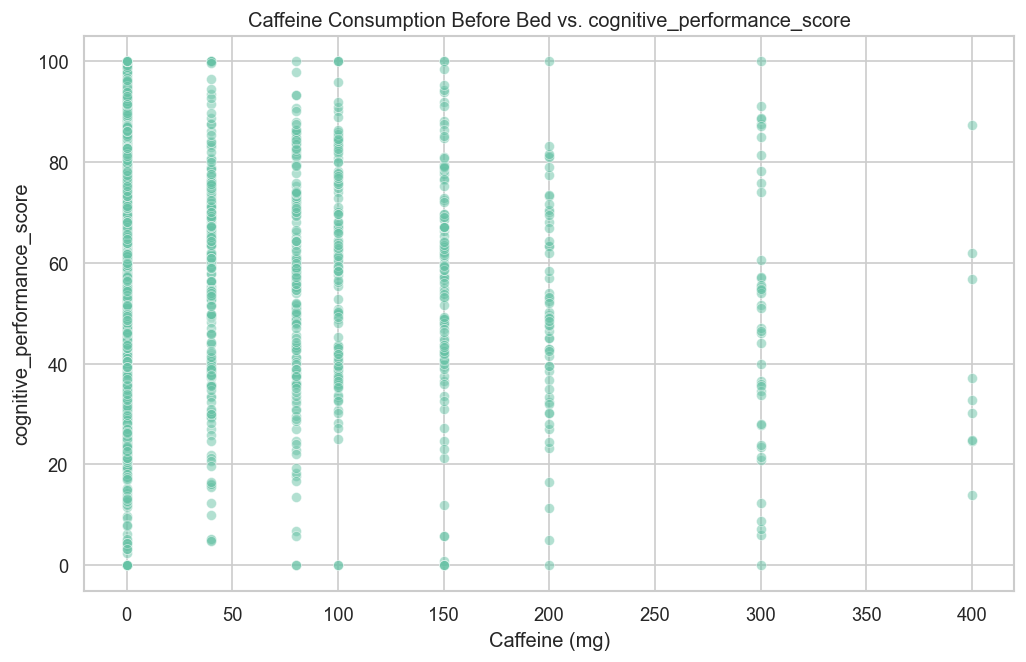

In [10]:
# Load the data
df = pd.read_csv('sleep_health_dataset.csv')

# Use a sample for better visibility if the dataset is very large
df_sample = df.sample(n=2000, random_state=42)

# Scatter Plot: Caffeine vs Sleep Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='caffeine_mg_before_bed', y='cognitive_performance_score', alpha=0.5)
plt.title('Caffeine Consumption Before Bed vs. cognitive_performance_score')
plt.xlabel('Caffeine (mg)')
plt.ylabel('cognitive_performance_score')
plt.show()

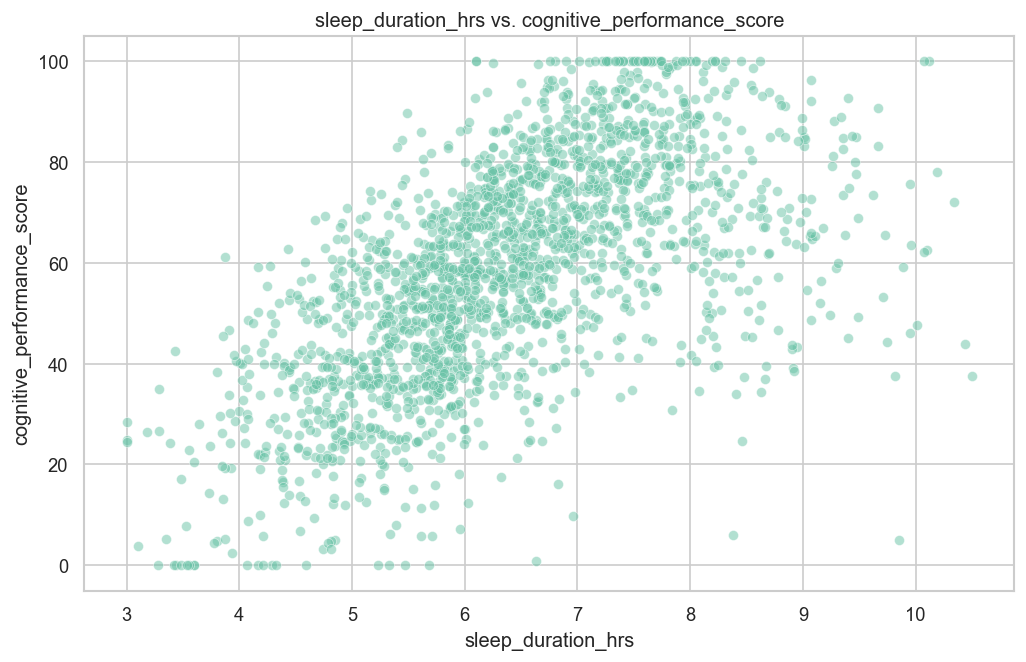

In [11]:
# Load the data
df = pd.read_csv('sleep_health_dataset.csv')

# Use a sample for better visibility if the dataset is very large
df_sample = df.sample(n=2000, random_state=42)

# Scatter Plot: Caffeine vs Sleep Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='sleep_duration_hrs', y='cognitive_performance_score', alpha=0.5)
plt.title('sleep_duration_hrs vs. cognitive_performance_score')
plt.xlabel('sleep_duration_hrs')
plt.ylabel('cognitive_performance_score')
plt.show()

<h1> Tree based models

<h2>encoding labels

In [12]:
label_encoder = LabelEncoder()
encoded_df_tree = df_regression.copy()
encoded_df_tree["occupation"] = label_encoder.fit_transform(encoded_df_tree["occupation"])
encoded_df_tree

,age,gender,occupation,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,sleep_aid_used,shift_work,heart_rate_resting_bpm,caffeine_mg_before_bed,cognitive_performance_score
0,29,Female,1,25.7,6.19,22.5,19.3,16,3,0,0,4.4,10.7,Morning,Healthy,0,0,63,0,73.4
1,55,Female,9,22.0,8.32,26.9,14.9,17,4,1,8,4.0,3.0,Neutral,Healthy,1,0,52,0,99.4
2,42,Male,6,25.0,3.74,20.2,16.2,26,4,1,28,7.8,3.6,Neutral,Both,0,1,72,0,2.5
3,37,Female,10,29.5,6.79,17.7,17.7,13,4,1,40,4.9,6.7,Morning,Healthy,0,0,71,0,67.8
4,23,Male,4,23.6,5.02,23.3,18.3,30,5,0,0,7.4,10.4,Neutral,Healthy,0,0,71,40,38.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,44,Female,6,25.9,6.77,26.8,24.6,18,0,1,19,5.4,7.7,Morning,Anxiety,1,0,72,0,89.4
99996,44,Female,5,30.2,4.90,21.6,22.3,9,1,0,32,6.8,9.3,Morning,Healthy,1,0,80,0,40.5
99997,39,Male,5,29.2,5.94,21.4,14.3,9,2,0,58,6.1,7.7,Neutral,Healthy,1,0,74,0,64.8
99998,33,Female,6,27.3,5.27,21.9,23.6,23,3,0,0,6.7,7.5,Neutral,Anxiety,1,0,68,150,40.8


In [13]:
columns_to_encode = ['gender', 'chronotype', 'mental_health_condition']

# Apply One-Hot Encoding
encoded_df_tree = pd.get_dummies(
    encoded_df_tree,
    columns=columns_to_encode,
    drop_first=False
)

# View the results to see the new binary columns

In [14]:
encoded_df_tree

,age,occupation,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,exercise_day,nap_duration_mins,...,cognitive_performance_score,gender_Female,gender_Male,chronotype_Evening,chronotype_Morning,chronotype_Neutral,mental_health_condition_Anxiety,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy
0,29,1,25.7,6.19,22.5,19.3,16,3,0,0,...,73.4,True,False,False,True,False,False,False,False,True
1,55,9,22.0,8.32,26.9,14.9,17,4,1,8,...,99.4,True,False,False,False,True,False,False,False,True
2,42,6,25.0,3.74,20.2,16.2,26,4,1,28,...,2.5,False,True,False,False,True,False,True,False,False
3,37,10,29.5,6.79,17.7,17.7,13,4,1,40,...,67.8,True,False,False,True,False,False,False,False,True
4,23,4,23.6,5.02,23.3,18.3,30,5,0,0,...,38.1,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,44,6,25.9,6.77,26.8,24.6,18,0,1,19,...,89.4,True,False,False,True,False,True,False,False,False
99996,44,5,30.2,4.90,21.6,22.3,9,1,0,32,...,40.5,True,False,False,True,False,False,False,False,True
99997,39,5,29.2,5.94,21.4,14.3,9,2,0,58,...,64.8,False,True,False,False,True,False,False,False,True
99998,33,6,27.3,5.27,21.9,23.6,23,3,0,0,...,40.8,True,False,False,False,True,True,False,False,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(encoded_df_tree.drop(columns="cognitive_performance_score"),encoded_df_tree["cognitive_performance_score"],test_size=0.3,random_state=42)

In [23]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}")

X_train shape: (68618, 25)
X_test shape: (29408, 25)
y_train shape: (68618,)
y_test shape: (29408,)


In [25]:
rt = RandomForestRegressor()
gb = GradientBoostingRegressor()
hgb = HistGradientBoostingRegressor()
ab  = AdaBoostRegressor()

In [26]:
rt.fit(X_train,y_train)
gb.fit(X_train,y_train)
hgb.fit(X_train,y_train)
ab.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [27]:
y_pred_rt = rt.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_hgb = hgb.predict(X_test)
y_pred_ab = ab.predict(X_test)

In [28]:
mae_rt = mean_absolute_error(y_pred_rt,y_test)
mae_gb = mean_absolute_error(y_pred_gb,y_test)
mae_hgb = mean_absolute_error(y_pred_hgb,y_test)
mae_ab = mean_absolute_error(y_pred_ab,y_test)

In [29]:
print(f"Rt MAE: {mae_rt}\nGb MAE: {mae_gb}\nHgb MAE: {mae_hgb}\nAb MAE: {mae_ab}")

Rt MAE: 6.269879896626768
Gb MAE: 6.049831563605729
Hgb MAE: 5.949112512754881
Ab MAE: 7.5298125792688735
